# 从分类器到对抗样本：决策边界的脆弱性

在上一篇 `02_logistic_softmax_nn.ipynb` 中，我们学习了逻辑回归和神经网络分类器，看到了它们如何在二维平面上画出清晰的决策边界。

但你是否知道，**只需对输入做微小扰动**，就能让分类器做出完全错误的判断？这就是**对抗样本攻击（Adversarial Examples）**。

本 notebook 将带你从熟悉的 2D 分类器出发，直观理解为什么线性模型和神经网络都容易被对抗样本欺骗。

In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

## 1. 生成有重叠的 2D 合成数据

两个类簇靠近排列（中心相距 2 个单位），使部分样本靠近决策边界——这些点是 FGSM 攻击的目标。

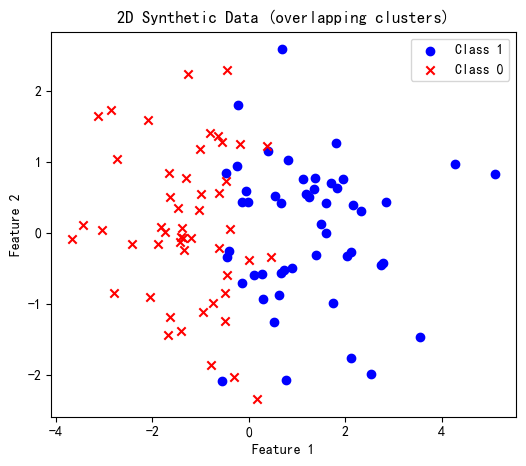

In [2]:
# 生成 2D 二分类数据：类簇靠近，部分重叠
x, y = make_blobs(n_samples=100, centers=[[-1, 0], [1, 0]], random_state=2, cluster_std=1.0)

plt.figure(figsize=(6, 5))
plt.scatter(x[y == 1, 0], x[y == 1, 1], color='blue', marker='o', label='Class 1')
plt.scatter(x[y == 0, 0], x[y == 0, 1], color='red', marker='x', label='Class 0')
plt.title('2D Synthetic Data (overlapping clusters)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## 2. 训练逻辑回归分类器

逻辑回归 = 一个线性层 + Sigmoid。决策边界是一条直线。

In [3]:
class LogisticRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

x_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)
x_train, x_test, y_train, y_test = train_test_split(x_tensor, y_tensor, test_size=0.2, random_state=42)

lr_model = LogisticRegression()
optimizer = torch.optim.Adam(lr_model.parameters(), lr=0.01)
criterion = nn.BCELoss()

for epoch in range(3000):
    optimizer.zero_grad()
    y_pred = lr_model(x_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    acc = (torch.round(lr_model(x_test)) == y_test).float().mean().item()
print(f'Test Accuracy: {acc:.3f}')

Test Accuracy: 1.000


## 3. 可视化决策边界

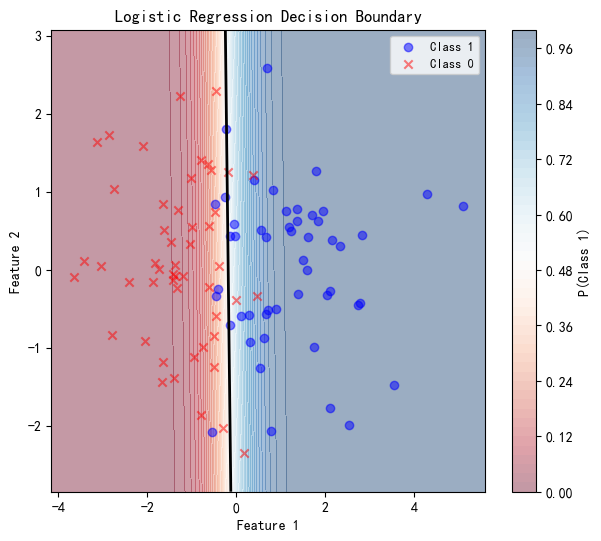

In [4]:
def plot_decision_boundary(model, x_data, y_data, title='Decision Boundary',
                         adv_x=None, adv_flipped=None, model_type='lr'):
    """绘制决策边界，对抗样本用星号标记（绿色=成功翻转，灰色=未翻转）。"""
    x1_min, x1_max = x_data[:, 0].min() - 0.5, x_data[:, 0].max() + 0.5
    x2_min, x2_max = x_data[:, 1].min() - 0.5, x_data[:, 1].max() + 0.5
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.02), np.arange(x2_min, x2_max, 0.02))
    grid_tensor = torch.tensor(np.c_[xx1.ravel(), xx2.ravel()], dtype=torch.float32)

    with torch.no_grad():
        if model_type == 'lr':
            z = model(grid_tensor).numpy().reshape(xx1.shape)
        else:
            z = torch.softmax(model(grid_tensor), dim=1)[:, 1].numpy().reshape(xx1.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx1, xx2, z, levels=50, alpha=0.4, cmap='RdBu')
    plt.colorbar(label='P(Class 1)')
    plt.contour(xx1, xx2, z, levels=[0.5], colors='black', linewidths=2)

    mask = y_data.astype(bool)
    plt.scatter(x_data[mask, 0], x_data[mask, 1], color='blue', marker='o', label='Class 1', alpha=0.5)
    plt.scatter(x_data[~mask, 0], x_data[~mask, 1], color='red', marker='x', label='Class 0', alpha=0.5)

    if adv_x is not None:
        if adv_flipped is not None:
            # 绿色星=成功翻转，灰色星=未翻转
            flipped = adv_x[adv_flipped]
            not_flipped = adv_x[~adv_flipped]
            if len(flipped) > 0:
                plt.scatter(flipped[:, 0], flipped[:, 1], color='lime', marker='*',
                           s=250, edgecolors='black', linewidths=0.5, label=f'Adversarial (flipped: {len(flipped)})', zorder=5)
            if len(not_flipped) > 0:
                plt.scatter(not_flipped[:, 0], not_flipped[:, 1], color='gray', marker='*',
                           s=150, alpha=0.4, label=f'Adversarial (not flipped: {len(not_flipped)})', zorder=4)
        else:
            plt.scatter(adv_x[:, 0], adv_x[:, 1], color='green', marker='*', s=200, label='Adversarial')

    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(loc='best', fontsize=9)
    plt.show()

plot_decision_boundary(lr_model, x, y, title='Logistic Regression Decision Boundary')

## 4. FGSM：快速梯度符号攻击

$$x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x \mathcal{L}(x, y))$$

沿着**让损失增大**的方向施加微小扰动，模型就可能犯错。

In [5]:
def fgsm_attack(model, x, y_true, epsilon):
    x_adv = x.clone().detach().requires_grad_(True)
    loss = criterion(model(x_adv), y_true)
    model.zero_grad()
    loss.backward()
    perturbation = epsilon * x_adv.grad.sign()
    return (x_adv + perturbation).detach(), perturbation.detach()

# 选择最靠近决策边界的 Class 1 样本
with torch.no_grad():
    probs = lr_model(x_tensor).squeeze()
boundary_margin = torch.abs(probs - 0.5)
class1_indices = np.where(y == 1)[0]
sample_idx = class1_indices[np.argmin(boundary_margin[class1_indices].numpy())]
x_sample = x_tensor[sample_idx:sample_idx + 1]
y_sample = y_tensor[sample_idx:sample_idx + 1]

with torch.no_grad():
    orig_prob = lr_model(x_sample).item()

# 用小 epsilon 攻击
epsilon = 0.3
x_adv_single, perturb = fgsm_attack(lr_model, x_sample, y_sample, epsilon)
with torch.no_grad():
    adv_prob = lr_model(x_adv_single).item()
flipped = adv_prob < 0.5

print(f'Original point:  ({x_sample[0,0]:.3f}, {x_sample[0,1]:.3f})')
print(f'Original P(Class 1): {orig_prob:.4f}')
print(f'Perturbation (eps={epsilon}): ({perturb[0,0]:.3f}, {perturb[0,1]:.3f})')
print(f'Adversarial point: ({x_adv_single[0,0]:.3f}, {x_adv_single[0,1]:.3f})')
print(f'Adversarial P(Class 1): {adv_prob:.4f}')
print(f'Attack result: {"FLIPPED!" if flipped else "not flipped"}')

Original point:  (-0.221, 1.804)
Original P(Class 1): 0.4975
Perturbation (eps=0.3): (-0.300, -0.300)
Adversarial point: (-0.521, 1.504)
Adversarial P(Class 1): 0.2779
Attack result: FLIPPED!


## 5. 可视化对抗样本如何跨越决策边界

绿色星 = 成功翻转（预测改变）；灰色星 = 未翻转（扰动不够大）。

Clean accuracy:       1.000
Adversarial accuracy: 0.900 (eps=0.4)
Flipped: 2/20 samples
  1->0 (Class 1 误判为 Class 0): 0 个
  0->1 (Class 0 误判为 Class 1): 2 个


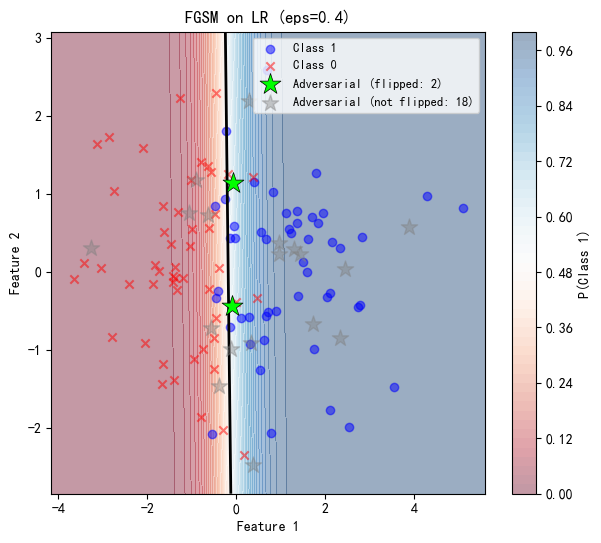

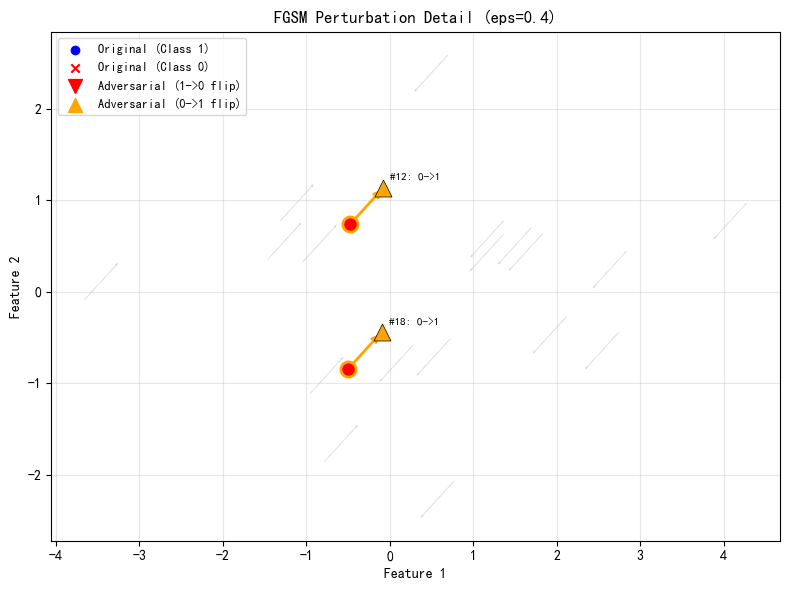

In [6]:
# 为测试集中所有样本生成对抗版本
epsilon_batch = 0.4
x_test_adv, _ = fgsm_attack(lr_model, x_test, y_test, epsilon_batch)

with torch.no_grad():
    orig_pred = torch.round(lr_model(x_test)).numpy().flatten()
    adv_pred = torch.round(lr_model(x_test_adv)).numpy().flatten()

y_true_np = y_test.numpy().flatten()
flipped_mask = orig_pred != adv_pred

# 细分翻转方向
flip_1_to_0 = (orig_pred == 1) & (adv_pred == 0)  # Class 1 -> Class 0
flip_0_to_1 = (orig_pred == 0) & (adv_pred == 1)  # Class 0 -> Class 1

acc_clean = (orig_pred == y_true_np).mean()
acc_adv = (adv_pred == y_true_np).mean()

print(f'Clean accuracy:       {acc_clean:.3f}')
print(f'Adversarial accuracy: {acc_adv:.3f} (eps={epsilon_batch})')
print(f'Flipped: {flipped_mask.sum()}/{len(flipped_mask)} samples')
print(f'  1->0 (Class 1 误判为 Class 0): {flip_1_to_0.sum()} 个')
print(f'  0->1 (Class 0 误判为 Class 1): {flip_0_to_1.sum()} 个')

# 可视化 1：决策边界 + 对抗点（按翻转方向着色）
plot_decision_boundary(lr_model, x, y,
                       title=f'FGSM on LR (eps={epsilon_batch})',
                       adv_x=x_test_adv.numpy(),
                       adv_flipped=flipped_mask)

# 可视化 2：箭头图（按翻转方向用不同颜色）
x_test_np = x_test.numpy()
x_test_adv_np = x_test_adv.numpy()

plt.figure(figsize=(8, 6))

# 未翻转的样本：灰色小箭头
for i in range(len(x_test_np)):
    if not flipped_mask[i]:
        plt.arrow(x_test_np[i, 0], x_test_np[i, 1],
                  x_test_adv_np[i, 0] - x_test_np[i, 0],
                  x_test_adv_np[i, 1] - x_test_np[i, 1],
                  head_width=0.02, length_includes_head=True,
                  color='gray', alpha=0.2, linewidth=0.5)

# 翻转 1->0 的样本：红色箭头
for i in range(len(x_test_np)):
    if flip_1_to_0[i]:
        plt.annotate('', xy=(x_test_adv_np[i, 0], x_test_adv_np[i, 1]),
                     xytext=(x_test_np[i, 0], x_test_np[i, 1]),
                     arrowprops=dict(arrowstyle='->', color='red', lw=2))
        plt.scatter(x_test_np[i, 0], x_test_np[i, 1], color='blue', s=120,
                    edgecolors='red', linewidths=2, zorder=5)
        plt.scatter(x_test_adv_np[i, 0], x_test_adv_np[i, 1], color='red',
                    marker='v', s=150, edgecolors='black', linewidths=0.5, zorder=6)
        plt.annotate(f'#{i}: 1->0', (x_test_adv_np[i, 0], x_test_adv_np[i, 1]),
                     fontsize=8, ha='left', xytext=(5, 5), textcoords='offset points')

# 翻转 0->1 的样本：橙色箭头
for i in range(len(x_test_np)):
    if flip_0_to_1[i]:
        plt.annotate('', xy=(x_test_adv_np[i, 0], x_test_adv_np[i, 1]),
                     xytext=(x_test_np[i, 0], x_test_np[i, 1]),
                     arrowprops=dict(arrowstyle='->', color='orange', lw=2))
        plt.scatter(x_test_np[i, 0], x_test_np[i, 1], color='red', s=120,
                    edgecolors='orange', linewidths=2, zorder=5)
        plt.scatter(x_test_adv_np[i, 0], x_test_adv_np[i, 1], color='orange',
                    marker='^', s=150, edgecolors='black', linewidths=0.5, zorder=6)
        plt.annotate(f'#{i}: 0->1', (x_test_adv_np[i, 0], x_test_adv_np[i, 1]),
                     fontsize=8, ha='left', xytext=(5, 5), textcoords='offset points')

plt.scatter([], [], color='blue', marker='o', label='Original (Class 1)')
plt.scatter([], [], color='red', marker='x', label='Original (Class 0)')
plt.scatter([], [], color='red', marker='v', s=100, label='Adversarial (1->0 flip)')
plt.scatter([], [], color='orange', marker='^', s=100, label='Adversarial (0->1 flip)')
plt.title(f'FGSM Perturbation Detail (eps={epsilon_batch})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(fontsize=9, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 逻辑回归 vs 神经网络：谁更容易被愚弄？

训练一个隐藏层为 3 个神经元的小神经网络，然后用相同的 FGSM 攻击两种模型。

NN Test Accuracy: 0.850


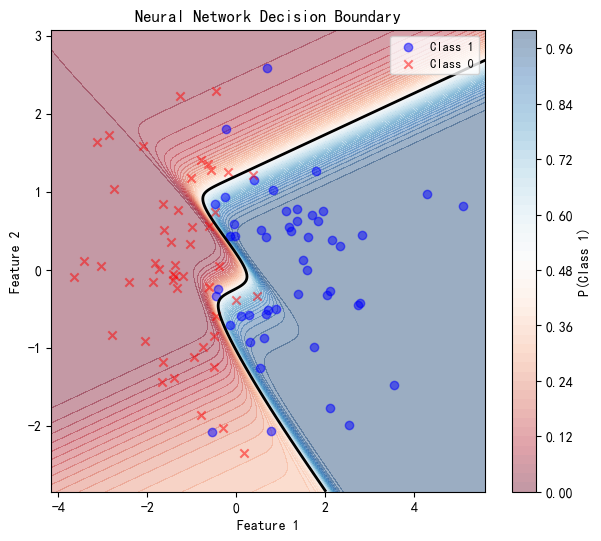

In [7]:
class SmallNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 3)
        self.out = nn.Linear(3, 2)
    def forward(self, x):
        return torch.log_softmax(self.out(torch.sigmoid(self.hidden(x))), dim=1)

nn_model = SmallNN()
optimizer_nn = torch.optim.Adam(nn_model.parameters(), lr=0.01)
criterion_nn = nn.NLLLoss()
y_train_long = y_train.view(-1).long()
y_test_long = y_test.view(-1).long()

for epoch in range(3000):
    optimizer_nn.zero_grad()
    loss = criterion_nn(nn_model(x_train), y_train_long)
    loss.backward()
    optimizer_nn.step()

with torch.no_grad():
    acc_nn = (torch.argmax(nn_model(x_test), dim=1) == y_test_long).float().mean().item()
print(f'NN Test Accuracy: {acc_nn:.3f}')

plot_decision_boundary(nn_model, x, y, title='Neural Network Decision Boundary', model_type='nn')

### 神经网络的对抗样本可视化

同样的 FGSM 攻击施加在神经网络上——注意决策边界是弯曲的，对抗样本需要跨越非线性边界。

NN Clean accuracy:      0.850
NN Adversarial accuracy: 0.750 (eps=0.4)
NN Flipped: 2/20 samples


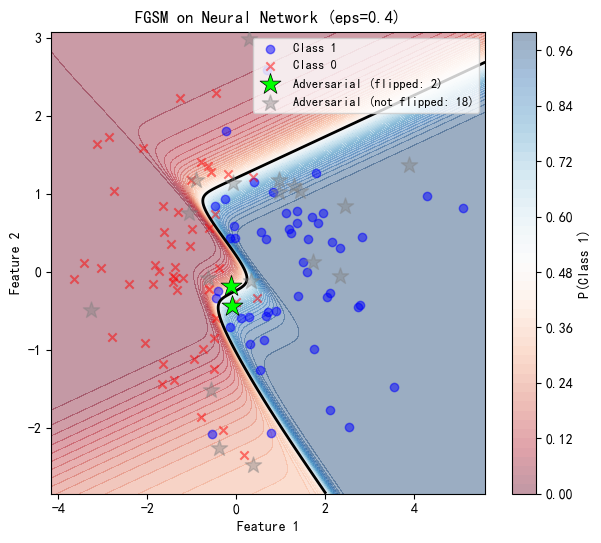

In [8]:
def fgsm_attack_nn(model, x, y_true, epsilon, crit):
    x_adv = x.clone().detach().requires_grad_(True)
    loss = crit(model(x_adv), y_true)
    model.zero_grad()
    loss.backward()
    return (x_adv + epsilon * x_adv.grad.sign()).detach()

# 攻击神经网络
x_test_adv_nn = fgsm_attack_nn(nn_model, x_test, y_test_long, epsilon_batch, criterion_nn)

with torch.no_grad():
    orig_pred_nn = torch.argmax(nn_model(x_test), dim=1).numpy()
    adv_pred_nn = torch.argmax(nn_model(x_test_adv_nn), dim=1).numpy()
flipped_nn = orig_pred_nn != adv_pred_nn

acc_nn_clean = (orig_pred_nn == y_test_long.numpy()).mean()
acc_nn_adv = (adv_pred_nn == y_test_long.numpy()).mean()
print(f'NN Clean accuracy:      {acc_nn_clean:.3f}')
print(f'NN Adversarial accuracy: {acc_nn_adv:.3f} (eps={epsilon_batch})')
print(f'NN Flipped: {flipped_nn.sum()}/{len(flipped_nn)} samples')

plot_decision_boundary(nn_model, x, y,
                       title=f'FGSM on Neural Network (eps={epsilon_batch})',
                       adv_x=x_test_adv_nn.numpy(),
                       adv_flipped=flipped_nn,
                       model_type='nn')

### 鲁棒性对比：不同 epsilon 下两种模型的准确率

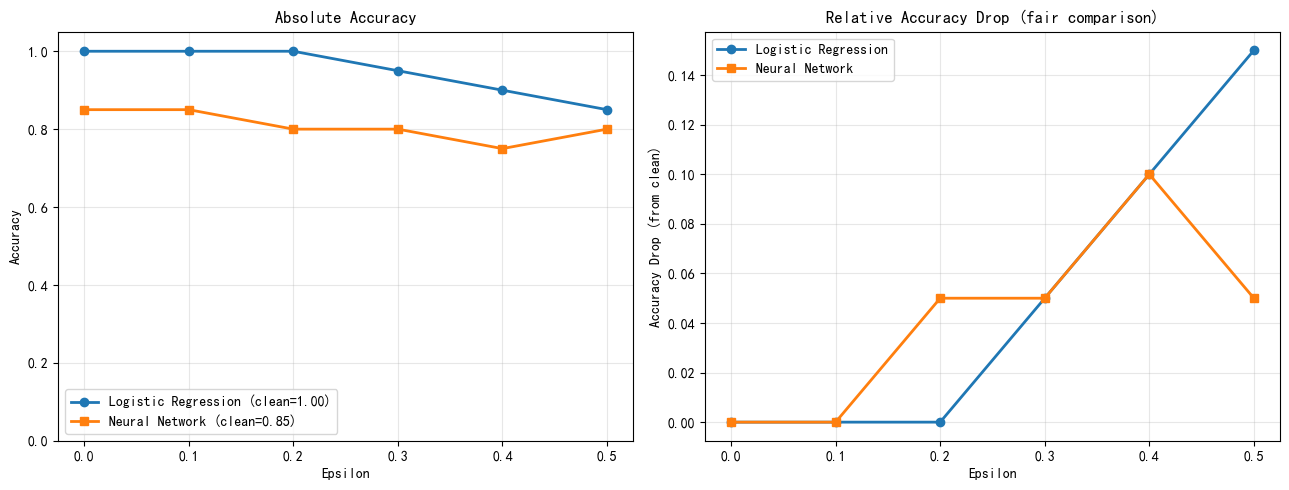

   eps |   LR acc   LR drop |   NN acc   NN drop
--------------------------------------------------
  0.00 |    1.000     0.000 |    0.850     0.000
  0.10 |    1.000     0.000 |    0.850     0.000
  0.20 |    1.000     0.000 |    0.800     0.050
  0.30 |    0.950     0.050 |    0.800     0.050
  0.40 |    0.900     0.100 |    0.750     0.100
  0.50 |    0.850     0.150 |    0.800     0.050

NOTE: LR clean acc = 1.00, NN clean acc = 0.85
右图(相对下降)消除了 clean accuracy 差异的影响，是更公平的鲁棒性对比。


In [9]:
epsilons = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
lr_accs = []
nn_accs = []

for eps in epsilons:
    # LR
    if eps == 0:
        xadv_lr = x_test
    else:
        xadv_lr, _ = fgsm_attack(lr_model, x_test, y_test, eps)
    with torch.no_grad():
        pred_lr = torch.round(lr_model(xadv_lr)).numpy().flatten()
    lr_accs.append((pred_lr == y_test.numpy().flatten()).mean())

    # NN
    if eps == 0:
        xadv_nn = x_test
    else:
        xadv_nn = fgsm_attack_nn(nn_model, x_test, y_test_long, eps, criterion_nn)
    with torch.no_grad():
        pred_nn = torch.argmax(nn_model(xadv_nn), dim=1).numpy()
    nn_accs.append((pred_nn == y_test_long.numpy()).mean())

lr_accs = np.array(lr_accs)
nn_accs = np.array(nn_accs)

# 双图：绝对准确率 + 相对下降
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 左图：绝对准确率
ax1.plot(epsilons, lr_accs, marker='o', linewidth=2, label=f'Logistic Regression (clean={lr_accs[0]:.2f})')
ax1.plot(epsilons, nn_accs, marker='s', linewidth=2, label=f'Neural Network (clean={nn_accs[0]:.2f})')
ax1.set_xlabel('Epsilon')
ax1.set_ylabel('Accuracy')
ax1.set_title('Absolute Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

# 右图：准确率下降（相对于各自 clean accuracy）
lr_drop = lr_accs[0] - lr_accs
nn_drop = nn_accs[0] - nn_accs
ax2.plot(epsilons, lr_drop, marker='o', linewidth=2, label='Logistic Regression')
ax2.plot(epsilons, nn_drop, marker='s', linewidth=2, label='Neural Network')
ax2.set_xlabel('Epsilon')
ax2.set_ylabel('Accuracy Drop (from clean)')
ax2.set_title('Relative Accuracy Drop (fair comparison)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'{"eps":>6s} | {"LR acc":>8s} {"LR drop":>9s} | {"NN acc":>8s} {"NN drop":>9s}')
print('-' * 50)
for eps, a_lr, d_lr, a_nn, d_nn in zip(epsilons, lr_accs, lr_drop, nn_accs, nn_drop):
    print(f'{eps:6.2f} | {a_lr:8.3f} {d_lr:9.3f} | {a_nn:8.3f} {d_nn:9.3f}')

print()
print('NOTE: LR clean acc = {:.2f}, NN clean acc = {:.2f}'.format(lr_accs[0], nn_accs[0]))
print('右图(相对下降)消除了 clean accuracy 差异的影响，是更公平的鲁棒性对比。')

## 结论

1. **两种模型都容易被对抗样本欺骗**：从右图（相对下降）可以清楚看到，FGSM 只需要很小的扰动就能让准确率显著下降。

2. **神经网络并不比线性模型更鲁棒**：在本实验中，非线性决策边界并没有提供天然的对抗鲁棒性——恰恰相反，NN 的弯曲边界梯度变化更剧烈，sign() 扰动反而更有效。这与 Goodfellow 等人的发现一致：对抗样本的根源不是模型的非线性，而是高维空间中微小扰动的**累积效应**。

3. **FGSM 的核心思想**：线性假说认为，在 $ 维空间中，每个维度施加 $\epsilon$ 的扰动，总位移可达到 $\epsilon \cdot \sqrt{d}$。在 2D 演示中这种累积效应有限，但在真实图像（ = 224 \times 224 \times 3$）中，对抗样本问题极其严重。

4. **安全启示**：防御对抗样本仍然是 AI 安全的重要研究方向。后续实验将展示更多攻击方法（C&W、DeepFool、UAP）和防御机制（对抗训练、随机平滑）。